# 06 - Predicción Final sobre Datos Sin Etiquetar
Aplica el pipeline de preprocesamiento y el modelo entrenado al conjunto de datos sin etiquetas.
Genera el archivo de salida con la columna `smoking_prediction`.

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import joblib

# ── Definir feature_engineering ANTES de cargar el config ─────────────────
def feature_engineering(df_in):
    df_out = df_in.copy()

    if 'systolic' in df_out.columns and 'relaxation' in df_out.columns:
        df_out['pulse_pressure'] = df_out['systolic'] - df_out['relaxation']

    if 'HDL' in df_out.columns and 'LDL' in df_out.columns:
        df_out['cholesterol_ratio'] = df_out['LDL'] / (df_out['HDL'] + 1e-9)

    if 'hemoglobin' in df_out.columns:
        df_out['hemoglobin_sq'] = df_out['hemoglobin'] ** 2

    if 'height(cm)' in df_out.columns and 'weight(kg)' in df_out.columns:
        df_out['bmi'] = df_out['weight(kg)'] / (df_out['height(cm)'] / 100) ** 2

    return df_out

# ── Ahora sí cargar el modelo ──────────────────────────────────────────────
print("Cargando modelo y configuración...")
model     = joblib.load('../models/best_model.pkl')
threshold = joblib.load('../models/best_threshold.pkl')
config    = joblib.load('../models/feature_config.pkl')

Cargando modelo y configuración...


In [6]:

# ── 1. Carga de datos sin etiquetar ──────────────────────────────────────
# Opción A: archivo local
# df_unlabeled = pd.read_excel('../data/raw/smoking_unlabeled.xlsx')

# Opción B: desde Google Sheets
SHEET_ID_UNLABELED = '1dpTMd0R0-YJ6psx8egWNR-IL5g6QPraL'
url = f'https://docs.google.com/spreadsheets/d/{SHEET_ID_UNLABELED}/export?format=csv'
df_unlabeled = pd.read_csv(url)

print(f"Dataset sin etiquetar cargado: {df_unlabeled.shape}")
df_unlabeled.head(3)


Dataset sin etiquetar cargado: (5692, 26)


,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar
0,27358,M,25,160,65,3.42,0.05,0.00,0.04,0.04,...,3.04,0.63,0.04,0.01,0.75,0.71,0.71,Y,0,Y
1,27364,M,30,180,80,3.46,0.04,0.01,0.04,0.04,...,4.21,0.59,0.04,0.04,0.79,1.13,1.33,Y,0,N
2,27368,M,55,165,60,3.42,0.00,0.01,0.04,0.04,...,2.04,0.63,0.04,0.01,1.08,1.29,2.00,Y,1,Y


In [7]:

# ── 2. Aplicar el mismo Feature Engineering ───────────────────────────────
feature_engineering = config['feature_engineering_fn']
df_fe = feature_engineering(df_unlabeled)

print(f"Shape tras feature engineering: {df_fe.shape}")


Shape tras feature engineering: (5692, 30)


In [8]:

# ── 3. Asegurar las mismas columnas que en entrenamiento ──────────────────
num_cols = config['num_cols']
cat_cols = config['cat_cols']
expected_cols = num_cols + cat_cols

# Verificar columnas faltantes
missing = set(expected_cols) - set(df_fe.columns)
if missing:
    print(f"⚠️  Columnas faltantes: {missing}")
    for col in missing:
        df_fe[col] = np.nan

# Seleccionar y ordenar columnas en el mismo orden que el entrenamiento
df_fe = df_fe[expected_cols]
print(f"Columnas alineadas: {df_fe.shape[1]}")


Columnas alineadas: 30


In [9]:

# ── 4. Generar predicciones ───────────────────────────────────────────────
y_proba = model.predict_proba(df_fe)[:, 1]
y_pred  = (y_proba >= threshold).astype(int)

print(f"Predicciones generadas: {len(y_pred)}")
print(f"Distribución predicha: {pd.Series(y_pred).value_counts().to_dict()}")
print(f"  Fumadores predichos:     {y_pred.sum()} ({y_pred.mean():.1%})")
print(f"  No fumadores predichos:  {(1-y_pred).sum()} ({(1-y_pred).mean():.1%})")


Predicciones generadas: 5692
Distribución predicha: {0: 2905, 1: 2787}
  Fumadores predichos:     2787 (49.0%)
  No fumadores predichos:  2905 (51.0%)


In [10]:

# ── 5. Construir el dataset de salida ─────────────────────────────────────
df_output = df_unlabeled.copy()
df_output['smoking_prediction'] = y_pred

print(f"Dataset de salida: {df_output.shape}")
print(f"Nueva columna 'smoking_prediction': {df_output['smoking_prediction'].value_counts().to_dict()}")
df_output.tail(5)


Dataset de salida: (5692, 27)
Nueva columna 'smoking_prediction': {0: 2905, 1: 2787}


,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking_prediction
5687,55676,F,40,170,65,3.13,0.01,0.01,0.04,0.04,...,0.50,0.04,0.00,0.58,0.29,0.42,Y,1,Y,0
5688,55681,F,45,160,50,2.92,0.04,0.04,0.04,0.04,...,0.58,0.04,0.01,0.83,0.50,0.58,Y,0,Y,0
5689,55683,F,55,160,50,2.84,0.04,0.04,0.04,0.04,...,0.50,0.04,0.00,0.71,0.46,0.50,Y,0,N,0
5690,55684,M,60,165,60,3.25,0.01,0.04,0.04,0.04,...,0.59,0.04,0.00,0.83,0.79,0.75,Y,0,N,1
5691,55691,M,55,160,65,3.54,0.01,0.00,0.04,0.04,...,0.63,0.04,0.01,1.08,1.21,1.71,Y,0,Y,1


In [11]:

# ── 6. Exportar resultados ────────────────────────────────────────────────
output_path = '../data/processed/smoking_predictions.csv'
df_output.to_csv(output_path, index=False)

print(f"✅ Predicciones exportadas a: {output_path}")
print(f"   Filas: {len(df_output)}")
print(f"   Columnas: {df_output.columns.tolist()}")


✅ Predicciones exportadas a: ../data/processed/smoking_predictions.csv
   Filas: 5692
   Columnas: ['ID', 'gender', 'age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'oral', 'dental caries', 'tartar', 'smoking_prediction']


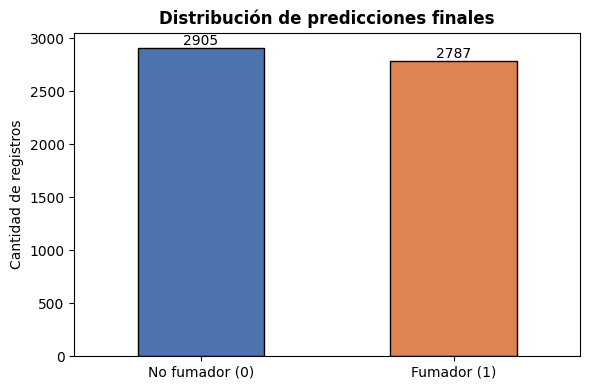


✅ Proceso de predicción completado exitosamente.


In [12]:

# ── 7. Vista previa final ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
pd.Series(y_pred).value_counts().plot(
    kind='bar', ax=ax,
    color=['#4C72B0', '#DD8452'],
    edgecolor='black'
)
ax.set_xticklabels(['No fumador (0)', 'Fumador (1)'], rotation=0)
ax.set_title('Distribución de predicciones finales', fontweight='bold')
ax.set_ylabel('Cantidad de registros')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig('../data/processed/final_predictions_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Proceso de predicción completado exitosamente.")
